<a href="https://colab.research.google.com/github/ekaratnida/Applied-machine-learning/blob/master/social-network/week4/FastRP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

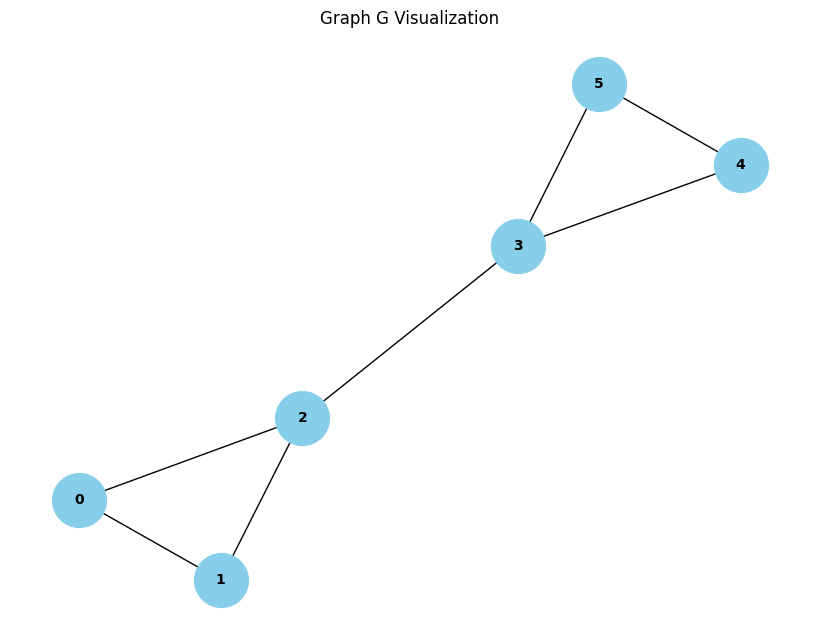

In [25]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Create a sample graph
G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (2, 3), (3, 4), (4, 5), (5, 3)])
plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=True, node_color='skyblue', node_size=1500, font_size=10, font_weight='bold')
plt.title("Graph G Visualization")
plt.show()

In [43]:
import numpy as np
import networkx as nx
from scipy.sparse import csr_matrix, diags # Import diags

def fast_rp(G, dim=128, k=3, node_self_influence=1.0, iteration_weights=None):

    if iteration_weights is None:
        iteration_weights = [1.0] * k

    print(f"1. iteration weights = {iteration_weights}")

    n_nodes = G.number_of_nodes()
    node_idx = {node: i for i, node in enumerate(G.nodes())}
    print(f"2. node_idx = {node_idx}")

    # Very sparse random projection (initial vectors)
    # Example: ~1-2 non-zero entries per vector (±1)
    R = np.zeros((n_nodes, dim))
    for i in range(n_nodes):
        # Very sparse: few random ±1 entries
        nnz = max(1, int(dim * 0.01))  # adjust sparsity
        print(f"nnz = {nnz}")
        indices = np.random.choice(dim, nnz, replace=False)
        print(f"indices = {indices}")
        R[i, indices] = np.random.choice([-1.0, 1.0], nnz)
        #print(f"R = {R}")

    embeddings = [R.copy()]

    # Iterative averaging
    A = nx.to_scipy_sparse_array(G, nodelist=list(G.nodes()), format='csr')
    print(f"A = {A.toarray()}")

    # Calculate inverse degrees and create a diagonal sparse matrix
    degrees = A.sum(axis=1).flatten() # sum rows to get degrees, flatten to 1D array
    print(f"degrees = {degrees}")
    inv_degrees = 1.0 / (degrees + 1e-10) # avoid division by zero
    D_inv = diags(inv_degrees, format='csr') # Create a diagonal sparse matrix using diags
    print(f"D_inv = {D_inv.toarray()}")

    current = R
    print(f"current = {current.shape}")
    print(f"A = {A.shape}")
    for i in range(k):
        # Average over neighbors: D^{-1} A * previous
        avg = D_inv @ ( A @ current ) #Multiply A by current effectly sums the embeddings of a node's neighbors
        # print(f"avg = {avg}")
        embeddings.append(avg)
        current = avg

    # Final weighted normalized embedding
    final = node_self_influence * embeddings[0]
    for i, w in enumerate(iteration_weights, 1):
        final += w * embeddings[i]

    # L2 normalize each row
    norms = np.linalg.norm(final, axis=1, keepdims=True)
    final /= (norms + 1e-10)

    return final

In [44]:
# Call the fast_rp function
dimensions = 64
iterations = 3
embeddings = fast_rp(G, dim=dimensions, k=iterations)

print(f"Generated embeddings with shape: {embeddings.shape}")
print("First embedding:\n", embeddings[0])

1. iteration weights = [1.0, 1.0, 1.0]
2. node_idx = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
nnz = 1
indices = [3]
nnz = 1
indices = [45]
nnz = 1
indices = [1]
nnz = 1
indices = [45]
nnz = 1
indices = [63]
nnz = 1
indices = [6]
A = [[0 1 1 0 0 0]
 [1 0 1 0 0 0]
 [1 1 0 1 0 0]
 [0 0 1 0 1 1]
 [0 0 0 1 0 1]
 [0 0 0 1 1 0]]
degrees = [2 2 3 3 2 2]
D_inv = [[0.5        0.         0.         0.         0.         0.        ]
 [0.         0.5        0.         0.         0.         0.        ]
 [0.         0.         0.33333333 0.         0.         0.        ]
 [0.         0.         0.         0.33333333 0.         0.        ]
 [0.         0.         0.         0.         0.5        0.        ]
 [0.         0.         0.         0.         0.         0.5       ]]
current = (6, 64)
A = (6, 6)
Generated embeddings with shape: (6, 64)
First embedding:
 [ 0.         -0.53419854  0.         -0.77086878  0.          0.
  0.02704803  0.          0.          0.          0.          0.
  0.          0

In [45]:
import numpy as np
import networkx as nx

# Let's use a simpler graph for demonstration
A_demo = np.array([
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
]) # Adjacency matrix for a triangle (nodes 0, 1, 2)

# Let's create some simple 'current' embeddings for these 3 nodes
# Each node has a 2-dimensional embedding for this example
current_demo = np.array([
    [1.0, 0.5],  # Embedding for node 0
    [0.2, 0.8],  # Embedding for node 1
    [0.7, 0.1]   # Embedding for node 2
])

print("Adjacency Matrix (A_demo):")
print(A_demo)
print("\nCurrent Embeddings (current_demo):")
print(current_demo)

# Perform A @ current
result_A_current = A_demo @ current_demo

print("\nResult of A_demo @ current_demo:")
print(result_A_current)

print("\n--- Explanation ---")
print("For Node 0 (first row of result): Neighbors are Node 1 and Node 2.\n  Sum of embeddings: current_demo[1] + current_demo[2] = [0.2, 0.8] + [0.7, 0.1] = [0.9, 0.9]")
print("For Node 1 (second row of result): Neighbors are Node 0 and Node 2.\n  Sum of embeddings: current_demo[0] + current_demo[2] = [1.0, 0.5] + [0.7, 0.1] = [1.7, 0.6]")
print("For Node 2 (third row of result): Neighbors are Node 0 and Node 1.\n  Sum of embeddings: current_demo[0] + current_demo[1] = [1.0, 0.5] + [0.2, 0.8] = [1.2, 1.3]")

Adjacency Matrix (A_demo):
[[0 1 1]
 [1 0 1]
 [1 1 0]]

Current Embeddings (current_demo):
[[1.  0.5]
 [0.2 0.8]
 [0.7 0.1]]

Result of A_demo @ current_demo:
[[0.9 0.9]
 [1.7 0.6]
 [1.2 1.3]]

--- Explanation ---
For Node 0 (first row of result): Neighbors are Node 1 and Node 2.
  Sum of embeddings: current_demo[1] + current_demo[2] = [0.2, 0.8] + [0.7, 0.1] = [0.9, 0.9]
For Node 1 (second row of result): Neighbors are Node 0 and Node 2.
  Sum of embeddings: current_demo[0] + current_demo[2] = [1.0, 0.5] + [0.7, 0.1] = [1.7, 0.6]
For Node 2 (third row of result): Neighbors are Node 0 and Node 1.
  Sum of embeddings: current_demo[0] + current_demo[1] = [1.0, 0.5] + [0.2, 0.8] = [1.2, 1.3]
